# Task 6: Netflix Business Insights Report
**Objective:** Create a business intelligence report from the Netflix dataset, combining exploratory analysis, dashboards and actionable insights

## Step 1: Exploratory data analysis
Profiled the full cleaned dataset: size, completeness, content duration, and how long after release titles were added to Netflix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/netflix_cleaned.csv", parse_dates=["date_added"])

#Overview
print("Rows x columns:", df.shape)
print("Date added range:", df["date_added"].min().date(), "to", df["date_added"].max().date())
print("Release year range:", df["release_year"].min(), "to", df["release_year"].max())
print("Countries (known):", df.loc[df["country"] != "Unknown", "country"].nunique())

#Movie duration 
movies = df[df["type"] == "Movie"].copy()
movies["minutes"] = movies["duration"].str.extract(r"(\d+)").astype(int)
print("\nMovie runtime (min): median", movies["minutes"].median(),
      "| mean", round(movies["minutes"].mean(), 1),
      "| shortest", movies["minutes"].min(), "| longest", movies["minutes"].max())

#TV Show seasons
shows = df[df["type"] == "TV Show"].copy()
shows["seasons"] = shows["duration"].str.extract(r"(\d+)").astype(int)
print("TV Shows with 1 season:", (shows["seasons"] == 1).sum(),
      f"({(shows['seasons'] == 1).mean():.1%} of TV Shows)")
print("Most seasons:", shows["seasons"].max())

#Content freshness: years between release and being added
df["added_lag"] = df["year_added"] - df["release_year"]
print("\nMedian years from release to Netflix:", df["added_lag"].median())
print("Added within 1 year of release:", f"{(df['added_lag'] <= 1).mean():.1%}")
print("Added 10+ years after release:", f"{(df['added_lag'] >= 10).mean():.1%}")
print("Rows where added year is BEFORE release year:", (df["added_lag"] < 0).sum())

Rows x columns: (8786, 12)
Date added range: 2008-01-01 to 2021-09-25
Release year range: 1925 to 2021
Countries (known): 85

Movie runtime (min): median 98.0 | mean 99.6 | shortest 3 | longest 312
TV Shows with 1 season: 1790 (67.2% of TV Shows)
Most seasons: 17

Median years from release to Netflix: 1.0
Added within 1 year of release: 55.0%
Added 10+ years after release: 15.3%
Rows where added year is BEFORE release year: 14


## Step 2: Key content trends and patterns
- **Additions over time:** how many titles Netflix added to its catalogue each year
- **Genres:** each title carries several genre tags (`listed_in`), so tags were split into one row each and counted

In [2]:
#1. Titles added to Netflix per year
added = df.groupby(["year_added", "type"]).size().unstack(fill_value=0)
added["Total"] = added.sum(axis=1)
added["YoY_%"] = added["Total"].pct_change().mul(100).round(1)
added["TV_share_%"] = (added["TV Show"] / added["Total"] * 100).round(1)
display(added.loc[2015:2021])

peak_add = added["Total"].idxmax()
print(f"Peak year for additions: {peak_add} ({added.loc[peak_add, 'Total']:,} titles)")

#2. Genres
genres = (df.assign(genre=df["listed_in"].str.split(","))
            .explode("genre"))
genres["genre"] = genres["genre"].str.strip()

print("\nUnique genre tags:", genres["genre"].nunique())
print("Average tags per title:", round(df["listed_in"].str.split(",").str.len().mean(), 1))

top_genres = genres["genre"].value_counts().head(10).to_frame("titles")
top_genres["% of all titles"] = (top_genres["titles"] / len(df) * 100).round(1)
top_genres

type,Movie,TV Show,Total,YoY_%,TV_share_%
year_added,,,,,
2015,56,26,82,241.7,31.7
2016,251,175,426,419.5,41.1
2017,836,349,1185,178.2,29.5
2018,1236,411,1647,39.0,25.0
2019,1422,591,2013,22.2,29.4
2020,1284,595,1879,-6.7,31.7
2021,993,505,1498,-20.3,33.7


Peak year for additions: 2019 (2,013 titles)

Unique genre tags: 42
Average tags per title: 2.2


,titles,% of all titles
genre,,
International Movies,2751,31.3
Dramas,2423,27.6
Comedies,1673,19.0
International TV Shows,1348,15.3
Documentaries,869,9.9
Action & Adventure,859,9.8
TV Dramas,761,8.7
Independent Movies,755,8.6
Children & Family Movies,641,7.3


## Step 3: Visual dashboards
- **Dashboard 1: Catalogue overview.** Headline numbers, titles added per year, TV Show share of additions
- **Dashboard 2: Content strategy.** Top genres, top countries, audience mix
- **Dashboard 3: Format and freshness.** Movie runtime, TV Show length, how quickly titles reach Netflix after release
- 2021 is a partial year

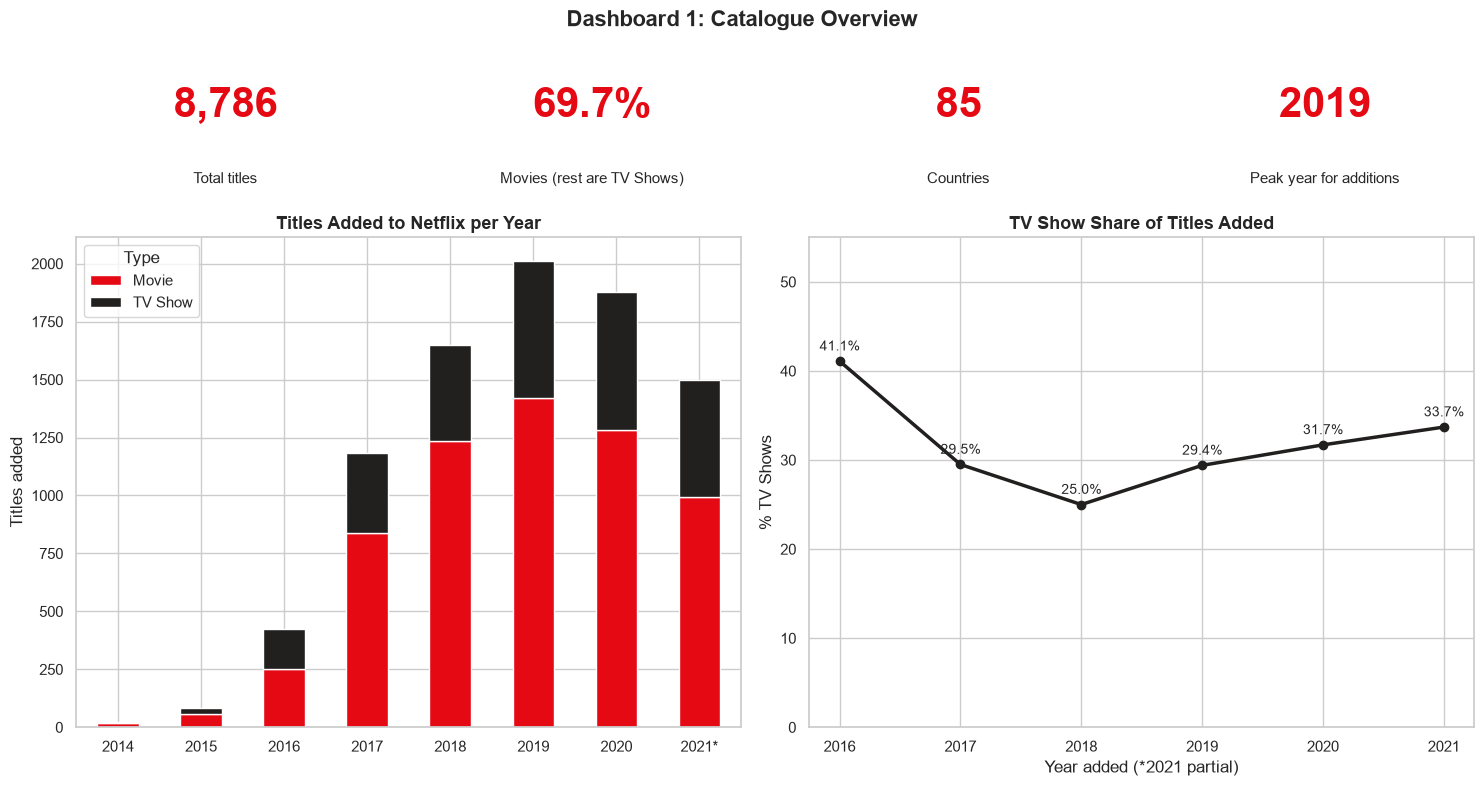

In [3]:
#Dashboard - 1 
sns.set_theme(style="whitegrid")
red, black, grey = "#E50914", "#221F1F", "#8C8C8C"

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[0.3, 1])

# KPI tiles
kpis = [
    (f"{len(df):,}", "Total titles"),
    (f"{(df['type'] == 'Movie').mean():.1%}", "Movies (rest are TV Shows)"),
    (f"{df.loc[df['country'] != 'Unknown', 'country'].nunique()}", "Countries"),
    (f"{added['Total'].idxmax()}", "Peak year for additions"),
]
for i, (value, label) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i]); ax.axis("off")
    ax.text(0.5, 0.55, value, ha="center", fontsize=30, fontweight="bold", color=red)
    ax.text(0.5, 0.1, label, ha="center", fontsize=11)

#titles added per year (stacked)
ax = fig.add_subplot(gs[1, 0:2])
added.loc[2014:2021, ["Movie", "TV Show"]].plot(kind="bar", stacked=True, color=[red, black],
                                               edgecolor="white", ax=ax)
ax.set_title("Titles Added to Netflix per Year", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Titles added")
ax.set_xticklabels([str(y) if y != 2021 else "2021*" for y in added.loc[2014:2021].index], rotation=0)
ax.legend(title="Type")

#TV Show share of additions
ax = fig.add_subplot(gs[1, 2:4])
s = added.loc[2016:2021, "TV_share_%"]
ax.plot(s.index, s.values, color=black, linewidth=2.5, marker="o")
for x, v in s.items():
    ax.text(x, v + 1.2, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_title("TV Show Share of Titles Added", fontsize=13, fontweight="bold")
ax.set_xlabel("Year added (*2021 partial)"); ax.set_ylabel("% TV Shows")
ax.set_ylim(0, 55)

plt.suptitle("Dashboard 1: Catalogue Overview", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../screenshots/task6_dashboard1_overview.png", dpi=150, bbox_inches="tight")
plt.show()

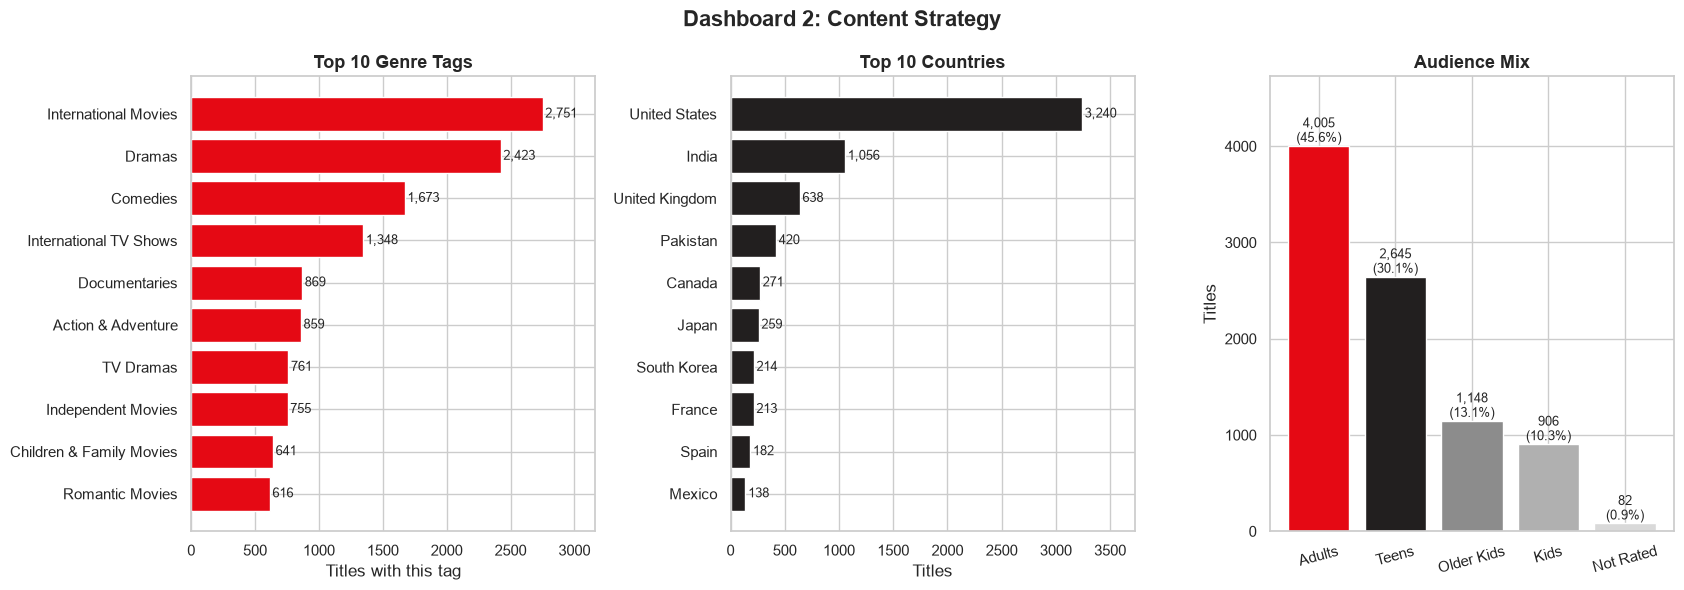

In [4]:
#Dashboard-2
known = df[df["country"] != "Unknown"]
top_countries = known["country"].value_counts().head(10)
top_gen = genres["genre"].value_counts().head(10)
aud = df["audience"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

axes[0].barh(top_gen.index[::-1], top_gen.values[::-1], color=red)
axes[0].set_title("Top 10 Genre Tags", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Titles with this tag")
for i, v in enumerate(top_gen.values[::-1]):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=9)
axes[0].set_xlim(0, top_gen.max() * 1.15)

axes[1].barh(top_countries.index[::-1], top_countries.values[::-1], color=black)
axes[1].set_title("Top 10 Countries", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Titles")
for i, v in enumerate(top_countries.values[::-1]):
    axes[1].text(v + 25, i, f"{v:,}", va="center", fontsize=9)
axes[1].set_xlim(0, top_countries.max() * 1.15)

order = ["Adults", "Teens", "Older Kids", "Kids", "Not Rated"]
axes[2].bar(order, aud[order].values, color=[red, black, grey, "#B0B0B0", "#D9D9D9"])
axes[2].set_title("Audience Mix", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Titles")
for i, v in enumerate(aud[order].values):
    axes[2].text(i, v + 40, f"{v:,}\n({v / len(df):.1%})", ha="center", fontsize=9)
axes[2].set_ylim(0, aud.max() * 1.18)
axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Dashboard 2: Content Strategy", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../screenshots/task6_dashboard2_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

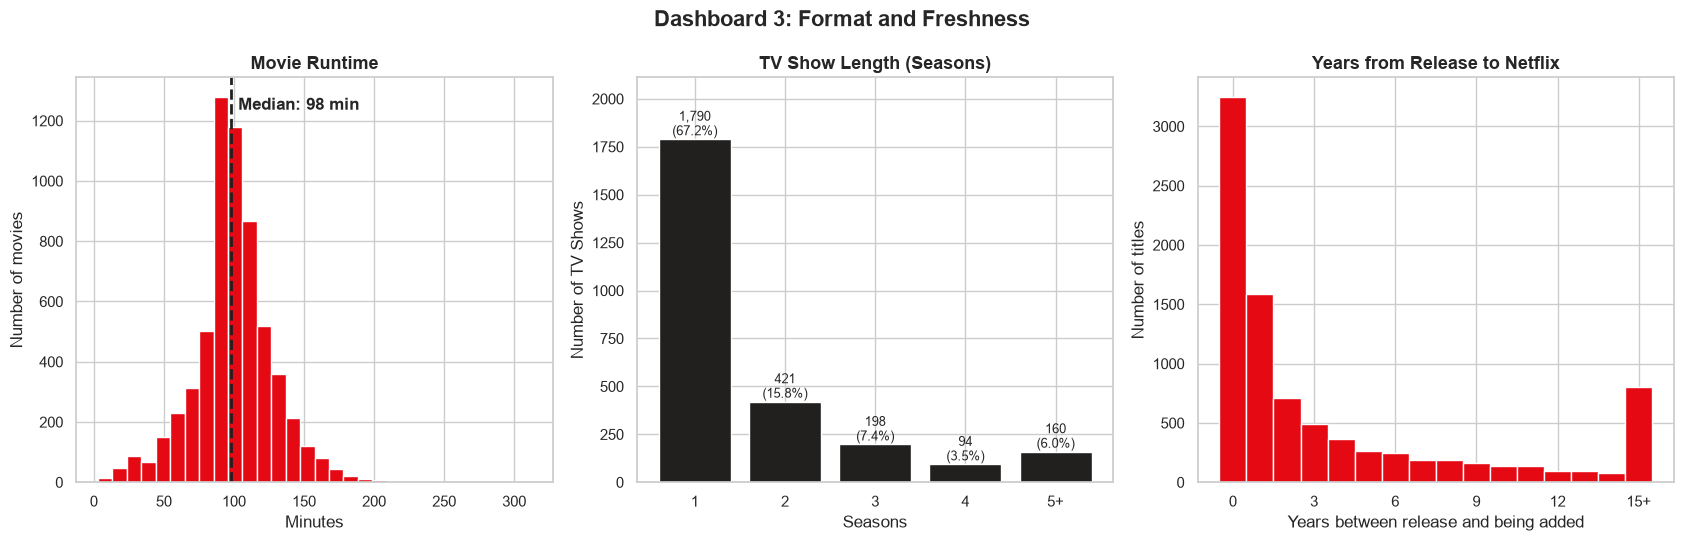

In [5]:
#Dashboard - 3
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Movie runtime
ax = axes[0]
ax.hist(movies["minutes"], bins=30, color=red, edgecolor="white")
ax.axvline(movies["minutes"].median(), color=black, linestyle="--", linewidth=2)
ax.text(movies["minutes"].median() + 5, ax.get_ylim()[1] * 0.92,
        f"Median: {movies['minutes'].median():.0f} min", fontweight="bold")
ax.set_title("Movie Runtime", fontsize=13, fontweight="bold")
ax.set_xlabel("Minutes"); ax.set_ylabel("Number of movies")

# TV Show seasons (5+ grouped)
ax = axes[1]
s = shows["seasons"].clip(upper=5).value_counts().sort_index()
labels = ["1", "2", "3", "4", "5+"]
ax.bar(labels, s.values, color=black)
for i, v in enumerate(s.values):
    ax.text(i, v + 20, f"{v:,}\n({v / len(shows):.1%})", ha="center", fontsize=9)
ax.set_title("TV Show Length (Seasons)", fontsize=13, fontweight="bold")
ax.set_xlabel("Seasons"); ax.set_ylabel("Number of TV Shows")
ax.set_ylim(0, s.max() * 1.18)

# Years from release to Netflix
ax = axes[2]
lag = df["added_lag"].clip(lower=0, upper=15)
ax.hist(lag, bins=range(0, 17), color=red, edgecolor="white", align="left")
ax.set_xticks(range(0, 16, 3)); ax.set_xticklabels(["0", "3", "6", "9", "12", "15+"])
ax.set_title("Years from Release to Netflix", fontsize=13, fontweight="bold")
ax.set_xlabel("Years between release and being added"); ax.set_ylabel("Number of titles")

plt.suptitle("Dashboard 3: Format and Freshness", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../screenshots/task6_dashboard3_format.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4: Actionable business insights
Each insight below is backed by a calculated number. To compare 2021 fairly, additions were measured over the **same window in every year**, because the data ends on 25 September 2021

In [6]:
#1 Jan to 25 Sep of each year
m, d = df["date_added"].dt.month, df["date_added"].dt.day
ytd = (m < 9) | ((m == 9) & (d <= 25))

like = df[ytd].groupby(["year_added", "type"]).size().unstack()
like["Total"] = like.sum(axis=1)
like["Total_YoY_%"] = like["Total"].pct_change().mul(100).round(1)
like["Movie_YoY_%"] = like["Movie"].pct_change().mul(100).round(1)
like["TV_YoY_%"] = like["TV Show"].pct_change().mul(100).round(1)
display(like.loc[2018:2021])

#other supporting evidence
known = df[df["country"] != "Unknown"]
by_year = pd.DataFrame({
    "US_share_%": known.groupby("year_added")["country"].apply(lambda s: (s == "United States").mean() * 100),
    "Intl_tag_%": df.groupby("year_added")["listed_in"].apply(lambda s: s.str.contains("International").mean() * 100),
    "Added_within_1yr_%": df.groupby("year_added")["added_lag"].apply(lambda s: (s <= 1).mean() * 100),
}).round(1)
display(by_year.loc[2016:2021])

print(f"Adults share of all titles: {(df['audience'] == 'Adults').mean():.1%}")
print(f"Kids titles: {(df['audience'] == 'Kids').sum()} ({(df['audience'] == 'Kids').mean():.1%})")
print(f"TV Shows with 3+ seasons: {(shows['seasons'] >= 3).sum()} ({(shows['seasons'] >= 3).mean():.1%} of TV Shows)")

type,Movie,TV Show,Total,Total_YoY_%,Movie_YoY_%,TV_YoY_%
year_added,,,,,,
2018,836.0,260.0,1096.0,30.3,40.5,5.7
2019,931.0,407.0,1338.0,22.1,11.4,56.5
2020,944.0,419.0,1363.0,1.9,1.4,2.9
2021,993.0,505.0,1498.0,9.9,5.2,20.5


,US_share_%,Intl_tag_%,Added_within_1yr_%
year_added,,,
2016,41.7,39.2,65.7
2017,34.7,50.6,59.7
2018,31.7,53.6,54.8
2019,39.1,46.8,51.6
2020,39.1,45.3,55.5
2021,41.5,42.5,50.8


Adults share of all titles: 45.6%
Kids titles: 906 (10.3%)
TV Shows with 3+ seasons: 452 (17.0% of TV Shows)


## Business insights and recommendations

### Executive summary
Netflix's catalogue is large (8,786 titles), international (85 countries) and growing. Each insight below states the evidence, a recommended action, and what the data cannot tell us

### Insight 1: Catalogue growth has not stalled
- **Evidence:** Over the same window (1 Jan to 25 Sep), titles added rose from 1,338 (2019) to 1,363 (2020) to **1,498 (2021), +9.9%**. The full-year 2021 figure (1,498, shown as −20.3%) looks like a drop only because the data ends in September.
- **Action:** Report additions on a like-for-like basis. Do not treat the 2021 dip as a decline.

### Insight 2: TV Shows are the growth engine
- **Evidence:** In 2021, TV Show additions grew **+20.5%** against **+5.2%** for Movies. TV Shows were 33.7% of additions in 2021 versus 23.7% in 2018. They also made up 53.2% of 2021 releases (Task 4).
- **Action:** Continue shifting commissioning towards series, and track watch time per title to confirm that series are driving retention.

### Insight 3: The international mix is narrowing
- **Evidence:** The US share of additions rose from **31.7% (2018) to 41.5% (2021)**. Titles tagged "International" fell from **53.6% to 42.5%**. The top 3 countries already supply 58.1% of the catalogue (Task 3).
- **Action:** Protect international variety by commissioning in mid-sized markets that already lean towards series (South Korea 77.1% and Japan 66.4% TV Show share), and reduce dependence on a few suppliers.
- **Caveat:** Each title records only one country, so co-productions are credited to one country.

### Insight 4: Long-running series are scarce
- **Evidence:** **67.2%** of TV Shows have a single season, and only **452 (17.0%)** have 3 or more seasons.
- **Action:** Prioritise renewals and multi-season franchises, which keep subscribers returning.
- **Caveat:** Some shows are limited series by design, and recent shows have had less time to run.

### Insight 5: Kids content is small but series-led
- **Evidence:** Kids titles number 906 (**10.3%**), against Adults at **45.6%**. Kids is the only audience group where TV Shows (51.2%) outnumber Movies (Task 2).
- **Action:** Test expanding family and kids series, which suit repeat viewing and household accounts.
- **Caveat:** This is a hypothesis. Catalogue counts show supply, not demand.

### Insight 6: The library is getting older
- **Evidence:** Titles added within a year of release fell from **65.7% (2016) to 50.8% (2021)**. Overall, 15.3% were added 10+ years after release.
- **Action:** Review the balance between new releases and library content so the catalogue stays fresh.
- **Caveat:** The dataset does not show which titles are Netflix originals and which are licensed.

### Data notes
- 287 titles (3.3%) have an unknown country, and 2,588 (29.5%) have an unknown director.
- 14 titles have an added year earlier than their release year, which is likely advance listing. They were kept.
- All figures describe the **catalogue**, not viewership, revenue or ratings.